# OilyGiant: selección de la región para perforar nuevos pozos

## Objetivo

La compañía minera **OilyGiant** quiere abrir **200 pozos nuevos** en una de tres regiones candidatas. Para cada región hay datos de exploración geológica de 100 000 puntos, con la reserva de petróleo medida (`product`).

Hay que elegir la región con **mayor beneficio esperado**, siempre que el **riesgo de pérdidas sea menor al 2.5 %**.

## Condiciones del negocio

- Al explorar una región se estudian **500 puntos** y se eligen los **200 mejores** según las predicciones del modelo.
- El presupuesto para desarrollar los 200 pozos es de **100 millones USD**.
- Cada unidad de producto (1 000 barriles) genera **4 500 USD** de ingresos.
- Solo se usa **regresión lineal**, porque es un modelo predecible e interpretable.

## Índice

1. Configuración
2. Carga y revisión de datos
3. Entrenamiento y validación del modelo por región
4. Punto de equilibrio
5. Cálculo del beneficio
6. Riesgo con bootstrapping
7. Conclusiones

## 1. Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 12345
DATA_DIR = Path("../data/raw")
REGIONS = [0, 1, 2]
FEATURES = ["f0", "f1", "f2"]
TARGET = "product"

# Condiciones del negocio
BUDGET = 100_000_000  # USD para 200 pozos
REVENUE_PER_UNIT = 4_500  # USD por unidad de producto (1 000 barriles)
POINTS_EXPLORED = 500
WELLS_SELECTED = 200
MAX_LOSS_RISK = 0.025
N_BOOTSTRAP = 1_000

sns.set_theme(style="whitegrid")

## 2. Carga y revisión de datos

Cada archivo corresponde a una región. `f0`, `f1` y `f2` son características geológicas anonimizadas y `product` es el volumen de reservas en miles de barriles.

In [2]:
regions = {r: pd.read_csv(DATA_DIR / f"geo_data_{r}.csv") for r in REGIONS}

pd.DataFrame(
    {
        r: {
            "filas": len(data),
            "nulos": int(data.isna().sum().sum()),
            "filas_duplicadas": int(data.duplicated().sum()),
            "id_duplicados": int(data["id"].duplicated().sum()),
            "product_medio": data[TARGET].mean(),
        }
        for r, data in regions.items()
    }
).T.astype({"filas": int, "nulos": int, "filas_duplicadas": int, "id_duplicados": int}).round(2)

,filas,nulos,filas_duplicadas,id_duplicados,product_medio
0,100000,0,0,10,92.50
1,100000,0,0,4,68.82
2,100000,0,0,4,95.00


No hay valores nulos ni filas completamente duplicadas, pero **algunos `id` se repiten con valores distintos**. Como no podemos saber cuál de las mediciones es la correcta y son muy pocos casos (< 0.02 %), eliminamos todas las filas con `id` repetido.

In [3]:
regions = {r: data[~data["id"].duplicated(keep=False)].reset_index(drop=True) for r, data in regions.items()}
{r: len(data) for r, data in regions.items()}

{0: 99980, 1: 99992, 2: 99992}

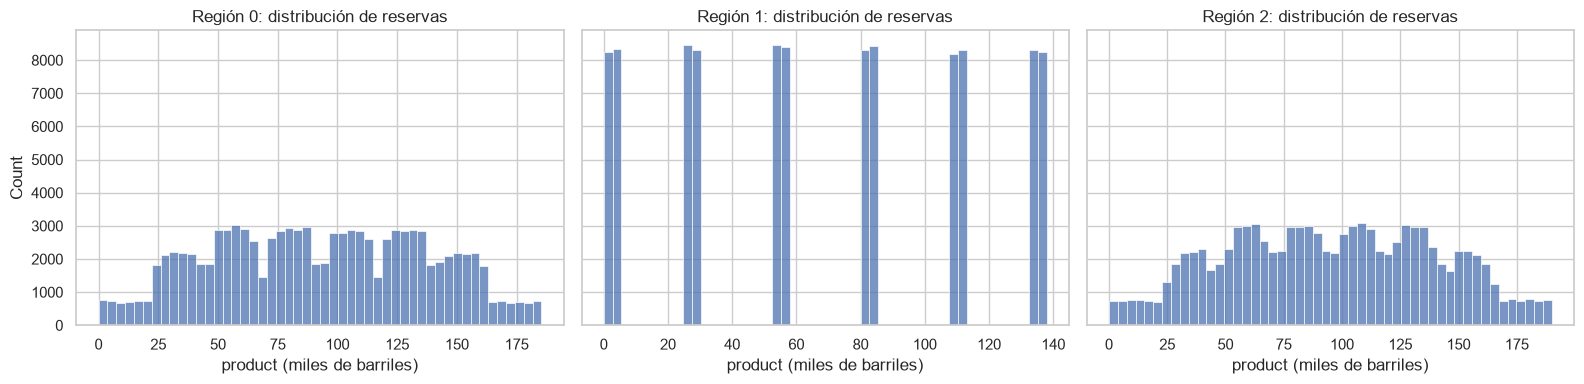

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (r, data) in zip(axes, regions.items()):
    sns.histplot(data[TARGET], bins=50, ax=ax)
    ax.set_title(f"Región {r}: distribución de reservas")
    ax.set_xlabel("product (miles de barriles)")
plt.tight_layout()
plt.show()

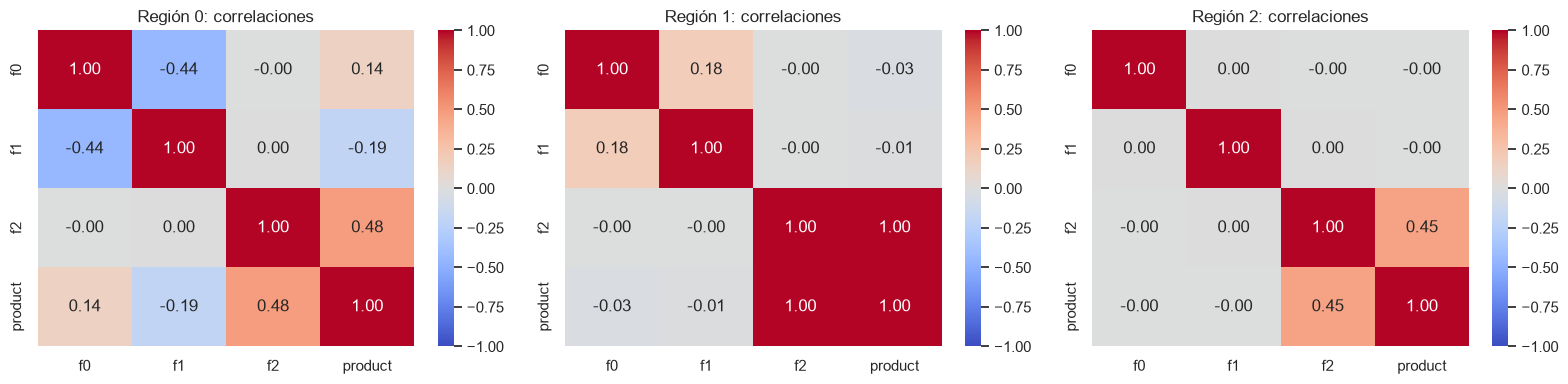

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (r, data) in zip(axes, regions.items()):
    sns.heatmap(data[FEATURES + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"Región {r}: correlaciones")
plt.tight_layout()
plt.show()

**Observaciones:**

- Las regiones 0 y 2 tienen una distribución de reservas continua, con una media cercana a 92–95 mil barriles.
- La región 1 tiene una distribución **discreta** (pocos valores distintos) y una media menor (≈ 69 mil barriles).
- En la región 1, `f2` tiene una correlación casi perfecta con `product`, así que ahí la regresión lineal debería ser muy precisa.

## 3. Entrenamiento y validación del modelo por región

Para cada región se dividen los datos en **75 % entrenamiento y 25 % validación**, se entrena una regresión lineal y se calcula el RMSE en validación.

In [6]:
def train_and_validate(data):
    """Entrena una regresión lineal y devuelve las predicciones y el objetivo real de validación."""
    X_train, X_valid, y_train, y_valid = train_test_split(
        data[FEATURES], data[TARGET], test_size=0.25, random_state=RANDOM_STATE
    )
    model = LinearRegression().fit(X_train, y_train)
    predictions = pd.Series(model.predict(X_valid), index=y_valid.index)
    return predictions, y_valid


validation = {r: train_and_validate(data) for r, data in regions.items()}

model_summary = pd.DataFrame(
    {
        r: {
            "reserva_media_predicha": preds.mean(),
            "reserva_media_real": y_valid.mean(),
            "RMSE": root_mean_squared_error(y_valid, preds),
        }
        for r, (preds, y_valid) in validation.items()
    }
).T
model_summary.round(2)

,reserva_media_predicha,reserva_media_real,RMSE
0,92.42,92.39,37.72
1,68.98,68.98,0.89
2,95.12,94.55,39.98


- La **región 1** tiene un RMSE < 1: el modelo es casi exacto.
- Las regiones **0 y 2** tienen más reservas de media, pero un RMSE de ≈ 38–40 mil barriles, es decir, **mucha incertidumbre** en las predicciones de cada pozo.

## 4. Punto de equilibrio

In [7]:
break_even_units = BUDGET / WELLS_SELECTED / REVENUE_PER_UNIT
print(f"Reservas mínimas por pozo para no tener pérdidas: {break_even_units:.1f} mil barriles")

model_summary["reserva_media_real"] - break_even_units

Reservas mínimas por pozo para no tener pérdidas: 111.1 mil barriles


0   -18.717621
1   -42.130738
2   -16.563293
Name: reserva_media_real, dtype: float64

Un pozo necesita **≈ 111.1 mil barriles** para cubrir su coste, y **la media de las tres regiones está por debajo**. Por eso no basta con perforar pozos al azar: hay que usar el modelo para **elegir los mejores puntos**.

## 5. Cálculo del beneficio

El beneficio se calcula eligiendo los pozos con **mayor reserva predicha**, pero sumando sus **reservas reales**, porque son las que generan ingresos.

In [8]:
def calculate_profit(predictions, target, n_wells=WELLS_SELECTED):
    """Beneficio de perforar los `n_wells` pozos con mayor reserva predicha."""
    best_wells = predictions.nlargest(n_wells).index
    return target.loc[best_wells].sum() * REVENUE_PER_UNIT - BUDGET


for r, (preds, y_valid) in validation.items():
    profit = calculate_profit(preds, y_valid)
    print(f"Región {r}: beneficio con los 200 mejores pozos de validación = {profit / 1e6:,.2f} M USD")

Región 0: beneficio con los 200 mejores pozos de validación = 31.36 M USD
Región 1: beneficio con los 200 mejores pozos de validación = 24.15 M USD
Región 2: beneficio con los 200 mejores pozos de validación = 24.66 M USD


Este cálculo usa los ≈ 25 000 puntos de validación, pero en la práctica solo se exploran **500 puntos** por región. Para estimar el beneficio real y su riesgo usamos bootstrapping.

## 6. Riesgo con bootstrapping

Se simulan **1 000 exploraciones**. En cada una se toman 500 puntos al azar (con reemplazo), se eligen los 200 con mayor predicción y se calcula el beneficio con sus reservas reales. Con esas simulaciones obtenemos:

- el **beneficio medio**,
- el **intervalo de confianza del 95 %**,
- el **riesgo de pérdidas** (proporción de simulaciones con beneficio negativo).

In [9]:
def bootstrap_profits(predictions, target, n_samples=N_BOOTSTRAP, random_state=RANDOM_STATE):
    """Distribución del beneficio al explorar POINTS_EXPLORED puntos y perforar los mejores."""
    rng = np.random.RandomState(random_state)
    profits = []
    for _ in range(n_samples):
        sample = predictions.sample(n=POINTS_EXPLORED, replace=True, random_state=rng)
        profits.append(calculate_profit(sample, target))
    return pd.Series(profits)


bootstrap = {r: bootstrap_profits(preds, y_valid) for r, (preds, y_valid) in validation.items()}

risk_summary = pd.DataFrame(
    {
        r: {
            "beneficio_medio_MUSD": profits.mean() / 1e6,
            "IC95_inferior_MUSD": profits.quantile(0.025) / 1e6,
            "IC95_superior_MUSD": profits.quantile(0.975) / 1e6,
            "riesgo_pérdida_%": (profits < 0).mean() * 100,
        }
        for r, profits in bootstrap.items()
    }
).T
risk_summary["cumple_riesgo"] = risk_summary["riesgo_pérdida_%"] < MAX_LOSS_RISK * 100
risk_summary.round(2)

,beneficio_medio_MUSD,IC95_inferior_MUSD,IC95_superior_MUSD,riesgo_pérdida_%,cumple_riesgo
0,4.32,-0.81,9.41,5.5,False
1,4.78,0.52,8.98,2.0,True
2,3.22,-1.73,8.44,12.3,False


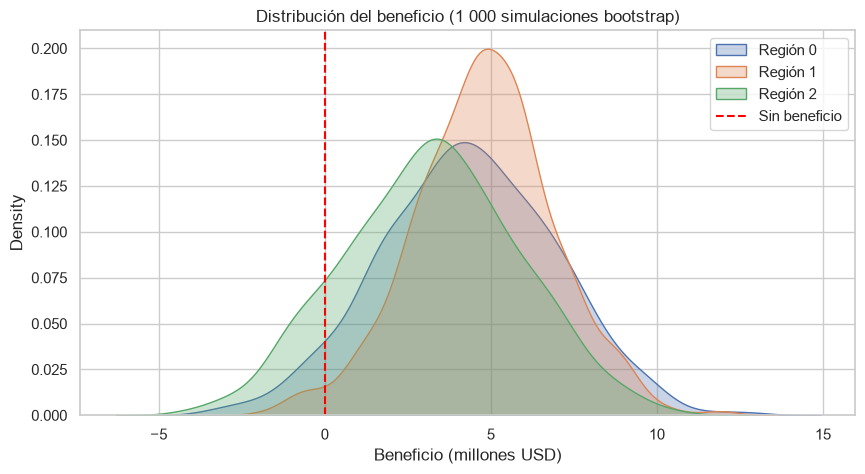

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for r, profits in bootstrap.items():
    sns.kdeplot(profits / 1e6, label=f"Región {r}", fill=True, alpha=0.3, ax=ax)
ax.axvline(0, color="red", linestyle="--", label="Sin beneficio")
ax.set_title("Distribución del beneficio (1 000 simulaciones bootstrap)")
ax.set_xlabel("Beneficio (millones USD)")
ax.legend()
plt.show()

In [11]:
eligible = risk_summary[risk_summary["cumple_riesgo"]]
best_region = eligible["beneficio_medio_MUSD"].idxmax()
print(f"Región recomendada: {best_region}")
risk_summary.loc[[best_region]].round(2)

Región recomendada: 1


,beneficio_medio_MUSD,IC95_inferior_MUSD,IC95_superior_MUSD,riesgo_pérdida_%,cumple_riesgo
1,4.78,0.52,8.98,2.0,True


## 7. Conclusiones

| Región | RMSE | Beneficio medio | IC 95 % | Riesgo de pérdida |
|---|---|---|---|---|
| 0 | 37.7 | 4.32 M USD | (−0.81, 9.41) M | 5.5 % ❌ |
| **1** | **0.9** | **4.78 M USD** | **(0.52, 8.98) M** | **2.0 % ✅** |
| 2 | 40.0 | 3.22 M USD | (−1.73, 8.44) M | 12.3 % ❌ |

- **Se recomienda desarrollar la región 1.** Es la única con un riesgo de pérdida inferior al 2.5 % y, además, tiene el mayor beneficio medio. Todo su intervalo de confianza del 95 % es positivo.
- Aunque la región 1 tiene **menos reservas de media**, el modelo predice sus reservas con mucha precisión (RMSE < 1). Por eso los 200 pozos elegidos son realmente buenos. En las regiones 0 y 2 el error del modelo hace que parte de los pozos elegidos rindan menos de lo esperado.
- Esto muestra que, en una decisión de inversión, **la precisión del modelo importa tanto como el valor medio esperado**.

**Limitaciones:**

- El riesgo de la región 1 (2.0 %) está **cerca del límite** del 2.5 %. Conviene repetir el análisis con más simulaciones o nuevos datos de exploración antes de invertir.
- La región 1 tiene una distribución de reservas discreta y una relación casi perfecta entre `f2` y `product`. Convendría confirmar con el equipo de geología que esos datos son fiables.